# Global Earthquakes

Reads from `quakes.sqlite`, populated by `fetch_quakes.py` (USGS FDSN catalog).

**Two coverage regimes** are mixed in this database on purpose:
- **M≥4.0 from 1965**, the WWSSN era. M4 detection is roughly comparable across this span.
- **M≥7.0 from 1900**, the long pre-WWSSN tail. Large quakes radiate enough energy that they were detected globally even by the sparse early-1900s networks, so M7+ counts are reliable back ~125 years.

Each plot is also saved to `figures/` as PNG. Re-execute the notebook to refresh them.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB = Path('quakes.sqlite')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

M4_COMPLETE_FROM = 1965  # WWSSN deployment — M4 catalog roughly comparable from here
NETWORK_UPGRADE_YEAR = 2000  # Modern digital regional networks fully online; M4 detection stabilizes
M7_COMPLETE_FROM = 1900  # Large quakes detected globally even by sparse early-1900s networks

def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=140, bbox_inches='tight', facecolor='white')

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(
        'SELECT id, time_ms, mag, mag_type, lat, lon, depth_km, place '
        'FROM quakes ORDER BY time_ms',
        conn,
    )
df['time'] = pd.to_datetime(df['time_ms'], unit='ms', utc=True)
df['year'] = df['time'].dt.year

latest = df['time'].max()
current_year = int(latest.year)
year_start = pd.Timestamp(f'{current_year}-01-01', tz='UTC')
year_end = pd.Timestamp(f'{current_year + 1}-01-01', tz='UTC')
year_fraction = (latest - year_start) / (year_end - year_start)
print(f'Loaded {len(df):,} events, {df["time"].min():%Y-%m-%d} → {latest:%Y-%m-%d}')
print(f'Current year ({current_year}) is {year_fraction:.1%} complete — handled separately in plots.')
df.head()

Loaded 530,895 events, 1900-01-05 → 2026-05-13
Current year (2026) is 36.4% complete — handled separately in plots.


,id,time_ms,mag,mag_type,lat,lon,depth_km,place,time,year
0,cent19000105190000000,-2208574800000,7.0,ms,-3.0,102.0,NaN,"Southern Sumatra, Indonesia",1900-01-05 19:00:00+00:00,1900
1,cent19000111090700000,-2208091980000,7.0,ms,-5.0,148.0,NaN,Bismarck Sea,1900-01-11 09:07:00+00:00,1900
2,cent19000120063300000,-2207323620000,7.3,mw,20.0,-105.0,NaN,"Jalisco, Mexico",1900-01-20 06:33:00+00:00,1900
3,cent19000131192200000,-2206327080000,7.5,mj,48.0,146.0,450.0,Sea of Okhotsk,1900-01-31 19:22:00+00:00,1900
4,cent19000511172300000,-2197694220000,7.0,mj,38.7,141.1,5.0,"Northern Honshu, Japan",1900-05-11 17:23:00+00:00,1900


## Magnitude vs Time

Each dot is one earthquake. M≥7.0 events highlighted as gold triangles. The grey shaded band on the right edge marks the partial current year. Note the pre-1965 region: only gold triangles appear because that's the M7-only historical window — the M4 catalog doesn't extend that far back.

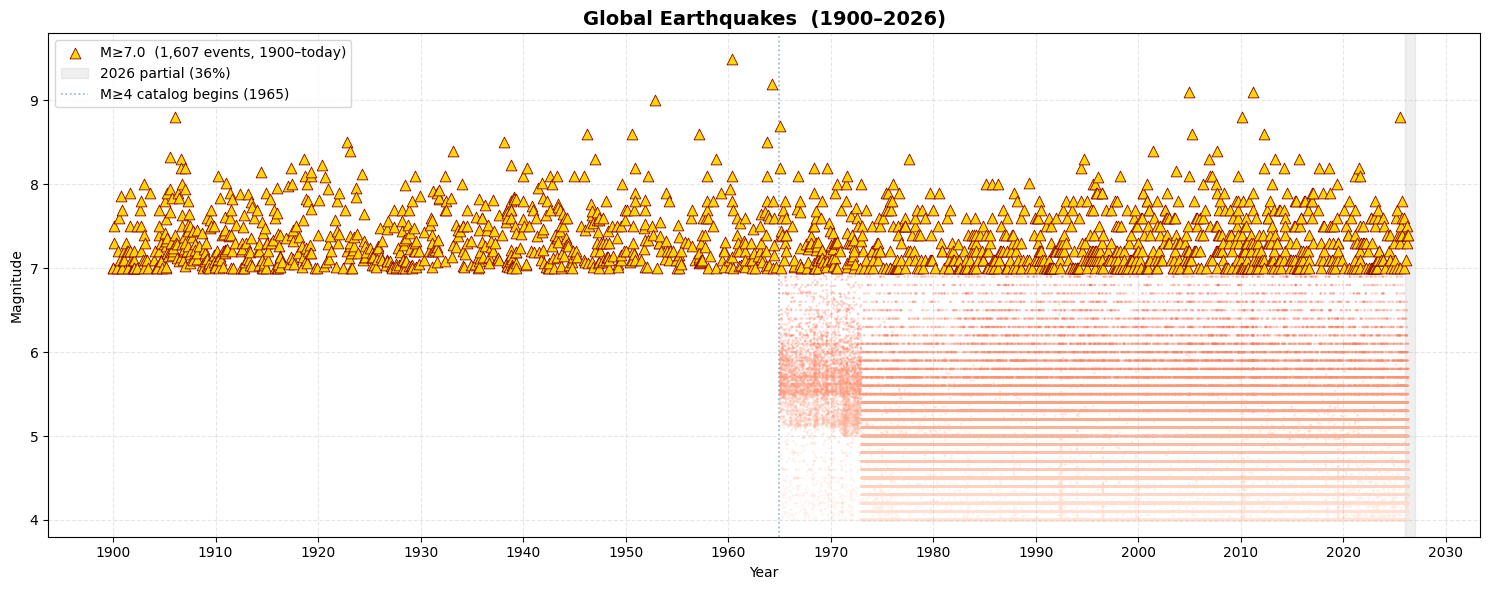

In [2]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(df['time'], df['mag'], c=df['mag'], cmap='Reds',
           alpha=0.25, s=3, linewidth=0)

major = df[df['mag'] >= 7.0]
ax.scatter(major['time'], major['mag'], c='gold', s=60, marker='^',
           edgecolors='darkred', linewidth=0.6, zorder=5,
           label=f'M≥7.0  ({len(major):,} events, 1900–today)')

ax.axvspan(year_start, year_end, color='grey', alpha=0.12, zorder=0,
           label=f'{current_year} partial ({year_fraction:.0%})')
ax.axvline(pd.Timestamp(f'{M4_COMPLETE_FROM}-01-01', tz='UTC'),
           color='steelblue', linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'M≥4 catalog begins ({M4_COMPLETE_FROM})')

ax.set_xlabel('Year')
ax.set_ylabel('Magnitude')
ax.set_title(f'Global Earthquakes  ({df["year"].min()}–{current_year})',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(3.8, df['mag'].max() + 0.3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
plt.tight_layout()
save_fig(fig, '01_magnitude_vs_time.png')
plt.show()

## Yearly Counts by Magnitude Band (M4 catalog only)

Showing complete years from 1965 onwards — the M≥4 catalog era. Pre-1965 data is M7-only and would create misleading sliver-bars.

Trend line is a linear fit on the **post-network-upgrade era (≥2000)** only — once digital regional networks were fully online and M4 detection had largely stabilized. A full-span fit would mostly track network-coverage gains rather than seismicity, so it's omitted.

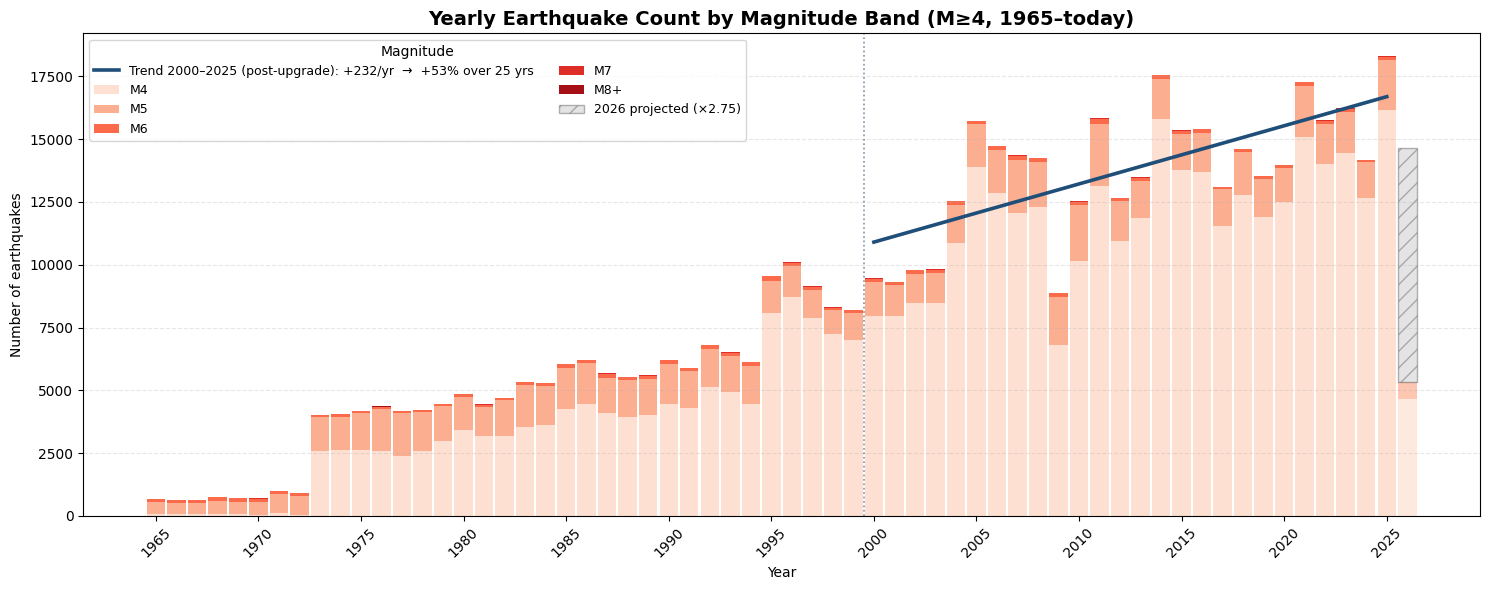

In [3]:
bands = [(4, 5, 'M4'), (5, 6, 'M5'), (6, 7, 'M6'), (7, 8, 'M7'), (8, 11, 'M8+')]
band_colors = ['#fee0d2', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

m4_era = df[df['year'] >= M4_COMPLETE_FROM]
by_year = pd.DataFrame({'year': sorted(m4_era['year'].unique())}).set_index('year')
for lo, hi, label in bands:
    sel = m4_era[(m4_era['mag'] >= lo) & (m4_era['mag'] < hi)]
    by_year[label] = sel.groupby('year').size()
by_year = by_year.fillna(0).astype(int)

complete_years = by_year.loc[by_year.index < current_year]
partial_row = by_year.loc[[current_year]] if current_year in by_year.index else None

fig, ax = plt.subplots(figsize=(15, 6))
year_to_x = {y: i for i, y in enumerate(by_year.index)}

bottom = np.zeros(len(complete_years))
for (lo, hi, label), color in zip(bands, band_colors):
    vals = complete_years[label].to_numpy()
    ax.bar([year_to_x[y] for y in complete_years.index], vals, bottom=bottom,
           color=color, width=0.9, label=label)
    bottom += vals

if partial_row is not None and year_fraction > 0:
    px = year_to_x[current_year]
    actual_total = int(partial_row.sum(axis=1).iloc[0])
    projected_total = actual_total / year_fraction
    bottom_p = 0.0
    for (lo, hi, label), color in zip(bands, band_colors):
        v = int(partial_row[label].iloc[0])
        ax.bar(px, v, bottom=bottom_p, color=color, width=0.9, alpha=0.7)
        bottom_p += v
    ax.bar(px, projected_total - actual_total, bottom=actual_total, color='lightgrey',
           width=0.9, alpha=0.6, hatch='//', edgecolor='grey',
           label=f'{current_year} projected (×{1/year_fraction:.2f})')

modern = complete_years.loc[complete_years.index >= NETWORK_UPGRADE_YEAR]
if len(modern) >= 5:
    m_yrs = modern.index.to_numpy()
    m_totals = modern.sum(axis=1).to_numpy()
    slope_m, intercept_m = np.polyfit(m_yrs, m_totals, 1)
    trend_m = slope_m * m_yrs + intercept_m
    n_yrs_m = m_yrs[-1] - m_yrs[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot([year_to_x[y] for y in m_yrs], trend_m, color='#1f4e79',
            linewidth=2.6,
            label=(f'Trend {m_yrs[0]}–{m_yrs[-1]} (post-upgrade): '
                   f'{slope_m:+.0f}/yr  →  {pct_m:+.0f}% over {n_yrs_m} yrs'))

if NETWORK_UPGRADE_YEAR in year_to_x:
    ax.axvline(year_to_x[NETWORK_UPGRADE_YEAR] - 0.5, color='#1f4e79',
               linestyle=':', linewidth=1.2, alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('Number of earthquakes')
ax.set_title('Yearly Earthquake Count by Magnitude Band (M≥4, 1965–today)',
             fontsize=14, fontweight='bold')
ax.legend(title='Magnitude', loc='upper left', ncol=2, fontsize=9)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
xpos = np.arange(len(by_year))
ax.set_xticks(xpos[::5])
ax.set_xticklabels(by_year.index[::5], rotation=45)
plt.tight_layout()
save_fig(fig, '02_yearly_by_band.png')
plt.show()

## M≥7.0 Yearly Counts — the detection-bias control (1900 → today)

Global instrumentation has been complete for M7+ for ~125 years, so this band is not affected by the same detection-improvement bias as the M4 band. If the trend in the M4 plot above were real seismicity, this line would rise too. If it stays flat, the apparent trend at lower magnitudes is detection, not actual quakes.

Two trend lines:
- **Black** — long span (1900 → last complete year). The cleanest possible answer to 'has Earth's seismicity changed?'
- **Blue** — WWSSN era only (1965 → last complete year). Same period as the M4 plot for direct comparison.

Red dashed line is the long-run mean across complete years; orange line is a 10-year rolling mean. The current year shows the actual partial count plus an annualized projection (hatched).

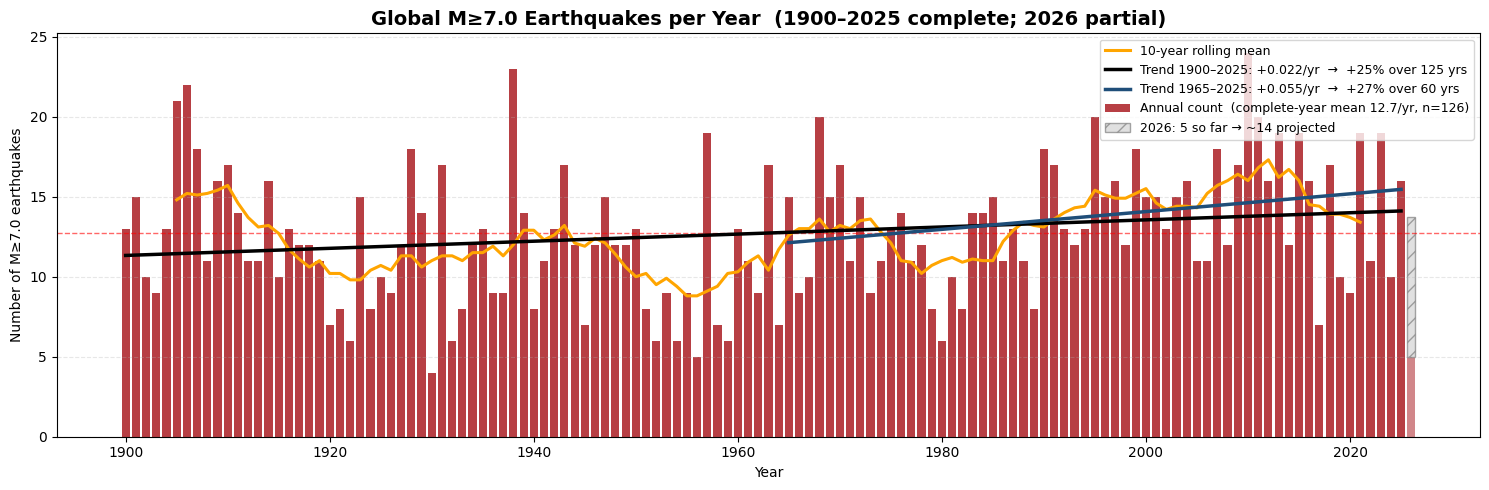

M≥7.0 stats over 126 complete years (1900–2025):
  mean:               12.71 per year
  median:             12.0 per year
  min:                4  (year 1930)
  max:                24  (year 2010)
  first-half mean:    11.70  (1900–1962)
  second-half mean:   13.73  (1963–2025)
  long-span slope:    +0.022 events/year  (+2.8 over 125 yrs)
  WWSSN-era slope:    +0.055 events/year  (+3.3 over 60 yrs)
  2026 (partial, 36.4%): 5 events so far → annualized ~14


In [4]:
big = df[df['mag'] >= 7.0]
yearly_all = big.groupby('year').size()
yearly_all = yearly_all.reindex(
    range(yearly_all.index.min(), yearly_all.index.max() + 1), fill_value=0
)
yearly = yearly_all[yearly_all.index < current_year]  # complete years only

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(yearly.index, yearly.values, color='#a50f15', alpha=0.8,
       label=f'Annual count  (complete-year mean {yearly.mean():.1f}/yr, n={len(yearly)})')

if current_year in yearly_all.index and year_fraction > 0:
    actual7 = int(yearly_all.loc[current_year])
    projected7 = actual7 / year_fraction
    ax.bar(current_year, actual7, color='#a50f15', alpha=0.5)
    ax.bar(current_year, projected7 - actual7, bottom=actual7,
           color='lightgrey', alpha=0.7, hatch='//', edgecolor='grey',
           label=f'{current_year}: {actual7} so far → ~{projected7:.0f} projected')

ax.axhline(yearly.mean(), color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.plot(yearly.index, yearly.rolling(10, center=True).mean(),
        color='orange', linewidth=2.2, label='10-year rolling mean')

# Long-span trend (1900 → today)
yi_long = yearly.index.to_numpy()
yv_long = yearly.values
slope_long, intercept_long = np.polyfit(yi_long, yv_long, 1)
trend_long = slope_long * yi_long + intercept_long
n_long = yi_long[-1] - yi_long[0]
pct_long = (trend_long[-1] - trend_long[0]) / trend_long[0] * 100
ax.plot(yi_long, trend_long, color='black', linewidth=2.5,
        label=f'Trend {yi_long[0]}–{yi_long[-1]}: {slope_long:+.3f}/yr  →  {pct_long:+.0f}% over {n_long} yrs')

# WWSSN-era trend (1965 → today), matching the M4 plot's window
yearly_modern = yearly[yearly.index >= M4_COMPLETE_FROM]
if len(yearly_modern) >= 5:
    yi_m = yearly_modern.index.to_numpy()
    yv_m = yearly_modern.values
    slope_m, intercept_m = np.polyfit(yi_m, yv_m, 1)
    trend_m = slope_m * yi_m + intercept_m
    n_m = yi_m[-1] - yi_m[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot(yi_m, trend_m, color='#1f4e79', linewidth=2.5,
            label=f'Trend {yi_m[0]}–{yi_m[-1]}: {slope_m:+.3f}/yr  →  {pct_m:+.0f}% over {n_m} yrs')

ax.set_xlabel('Year')
ax.set_ylabel('Number of M≥7.0 earthquakes')
ax.set_title(f'Global M≥7.0 Earthquakes per Year  ({yi_long[0]}–{yi_long[-1]} complete; {current_year} partial)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_fig(fig, '03_m7_yearly.png')
plt.show()

n_years = len(yearly)
split = yearly.index.min() + n_years // 2
first_half = yearly[yearly.index < split].mean()
second_half = yearly[yearly.index >= split].mean()
print(f'M≥7.0 stats over {n_years} complete years ({yearly.index.min()}–{yearly.index.max()}):')
print(f'  mean:               {yearly.mean():.2f} per year')
print(f'  median:             {yearly.median():.1f} per year')
print(f'  min:                {yearly.min()}  (year {yearly.idxmin()})')
print(f'  max:                {yearly.max()}  (year {yearly.idxmax()})')
print(f'  first-half mean:    {first_half:.2f}  ({yearly.index.min()}–{split - 1})')
print(f'  second-half mean:   {second_half:.2f}  ({split}–{yearly.index.max()})')
print(f'  long-span slope:    {slope_long:+.3f} events/year  ({slope_long * n_long:+.1f} over {n_long} yrs)')
if len(yearly_modern) >= 5:
    print(f'  WWSSN-era slope:    {slope_m:+.3f} events/year  ({slope_m * n_m:+.1f} over {n_m} yrs)')
if current_year in yearly_all.index:
    actual7 = int(yearly_all.loc[current_year])
    print(f'  {current_year} (partial, {year_fraction:.1%}): {actual7} events so far '
          f'→ annualized ~{actual7 / year_fraction:.0f}')

## Magnitude Distribution (M≥4 catalog only)

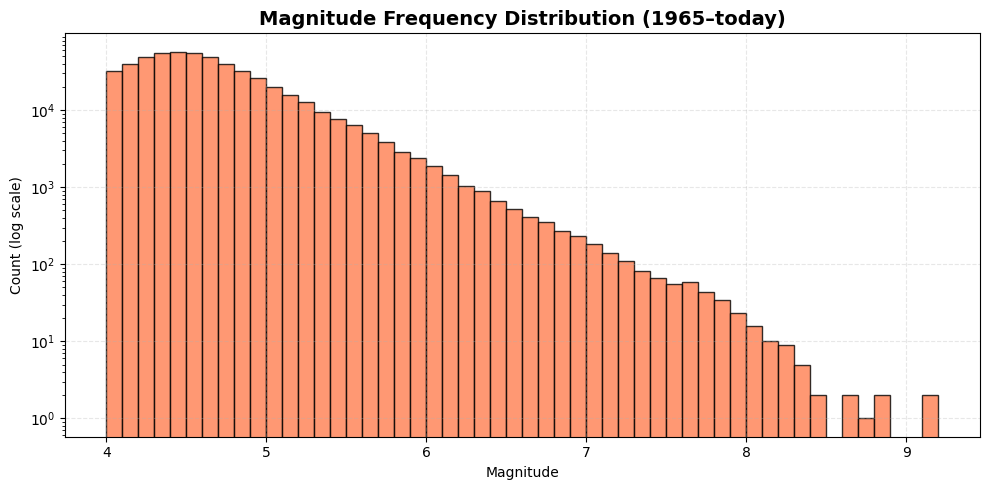

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(m4_era['mag'], bins=np.arange(4.0, m4_era['mag'].max() + 0.2, 0.1),
        color='coral', edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'Magnitude Frequency Distribution ({M4_COMPLETE_FROM}–today)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
save_fig(fig, '04_magnitude_distribution.png')
plt.show()

## Stats

In [6]:
complete_df = df[df['year'] < current_year]
partial_df = df[df['year'] == current_year]
m4_complete = complete_df[complete_df['year'] >= M4_COMPLETE_FROM]
n_m4_years = m4_complete['year'].nunique()
m7_complete = complete_df[complete_df['mag'] >= 7.0]
n_m7_years = m7_complete['year'].nunique()

print(f'Total events:             {len(df):,}  ({len(complete_df):,} in complete years + '
      f'{len(partial_df):,} in {current_year} partial)')
print(f'M≥4 catalog range:        {m4_complete["time"].min():%Y-%m-%d}  →  '
      f'{m4_complete["time"].max():%Y-%m-%d}  ({n_m4_years} complete years)')
print(f'M≥7 catalog range:        {m7_complete["time"].min():%Y-%m-%d}  →  '
      f'{m7_complete["time"].max():%Y-%m-%d}  ({n_m7_years} complete years)')
print(f'Partial year:             {current_year}  ({year_fraction:.1%} elapsed, '
      f'{len(partial_df):,} events so far)')
print(f'Magnitude range:          {df["mag"].min():.1f}  →  {df["mag"].max():.1f}')
print()
print(f'Counts by magnitude band, M≥4 era ({M4_COMPLETE_FROM}–{current_year - 1}, complete years):')
for lo, hi, label in bands:
    n = ((m4_complete['mag'] >= lo) & (m4_complete['mag'] < hi)).sum()
    rate = n / n_m4_years
    print(f'  {label:5s}  {n:>9,}    ({rate:>7.1f}/yr)')
print()
print('Top 10 largest events:')
top = df.nlargest(10, 'mag')[['time', 'mag', 'place']]
for _, row in top.iterrows():
    print(f'  {row["time"]:%Y-%m-%d}  M{row["mag"]:.1f}  {row["place"]}')

Total events:             530,895  (525,572 in complete years + 5,323 in 2026 partial)
M≥4 catalog range:        1965-01-01  →  2025-12-31  (61 complete years)
M≥7 catalog range:        1900-01-05  →  2025-12-08  (126 complete years)
Partial year:             2026  (36.4% elapsed, 5,323 events so far)
Magnitude range:          3.4  →  9.5

Counts by magnitude band, M≥4 era (1965–2025, complete years):
  M4       430,940    ( 7064.6/yr)
  M5        85,390    ( 1399.8/yr)
  M6         7,639    (  125.2/yr)
  M7           792    (   13.0/yr)
  M8+           49    (    0.8/yr)

Top 10 largest events:
  1960-05-22  M9.5  1960 Great Chilean Earthquake (Valdivia Earthquake)
  1964-03-28  M9.2  The 1964 Prince William Sound, Alaska Earthquake
  2004-12-26  M9.1  2004 Sumatra - Andaman Islands Earthquake
  2011-03-11  M9.1  2011 Great Tohoku Earthquake, Japan
  1952-11-04  M9.0  89 km ESE of Petropavlovsk-Kamchatsky, Russia
  1906-01-31  M8.8  1906 Ecuador-Colombia Earthquake
  2010-02-27  M8.8